In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

import anndata as ad
import scanpy as sc
import muon as mu
from muon import atac as ac

sc.settings.verbosity = 2
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False)
mpl.rcParams["figure.figsize"] = (6, 5)

print(f"scanpy  {sc.__version__}")
print(f"anndata {ad.__version__}")
print(f"muon    {mu.__version__}")

scanpy  1.9.6
anndata 0.9.2
muon    0.1.5


In [2]:
DATA_PATH = "../data/raw/SEAAD_MTG_ATACseq_all-nuclei.2024-12-06.h5ad"

adata = sc.read_h5ad(DATA_PATH)
print(adata)
print("\n--- obs columns ---")
print(adata.obs.columns.tolist())
print("\n--- var columns ---")
print(adata.var.columns.tolist())

AnnData object with n_obs × n_vars = 1123761 × 218882
    obs: 'sample_id', 'Neurotypical reference', 'Donor ID', 'Organism', 'Brain Region', 'Sex', 'Gender', 'Age at Death', 'Race (choice=White)', 'Race (choice=Black/ African American)', 'Race (choice=Asian)', 'Race (choice=American Indian/ Alaska Native)', 'Race (choice=Native Hawaiian or Pacific Islander)', 'Race (choice=Unknown or unreported)', 'Race (choice=Other)', 'specify other race', 'Hispanic/Latino', 'Highest level of education', 'Years of education', 'PMI', 'Fresh Brain Weight', 'Brain pH', 'Overall AD neuropathological Change', 'Thal', 'Braak', 'CERAD score', 'Overall CAA Score', 'Highest Lewy Body Disease', 'Total Microinfarcts (not observed grossly)', 'Total microinfarcts in screening sections', 'Atherosclerosis', 'Arteriolosclerosis', 'LATE', 'Cognitive Status', 'Last CASI Score', 'Interval from last CASI in months', 'Last MMSE Score', 'Interval from last MMSE in months', 'Last MOCA Score', 'Interval from last MOCA in m

In [3]:
# Quick peek at cell metadata and peak names
display(adata.obs.head(3))
display(adata.var.head(3))

# Feature format (e.g. "chr1:1000-2000")
print("\nFirst 5 peak names:", adata.var_names[:5].tolist())

,sample_id,Neurotypical reference,Donor ID,Organism,Brain Region,Sex,Gender,Age at Death,Race (choice=White),Race (choice=Black/ African American),...,Class,Subclass confidence,Subclass,Supertype confidence,Supertype (non-expanded),Supertype,RNA Quality Control Score,Quality Control Clusters,Continuous Pseudo-progression Score,Severely Affected Donor
index,,,,,,,,,,,,,,,,,,,,,
CTTCTAACACAAGGGT-L8AT_211215_01_G07-1149773124,CTTCTAACACAAGGGT-L8AT_211215_01_G07-1149773124,False,H21.33.025,human,Human MTG,Female,Female,88.0,Checked,Unchecked,...,Neuronal: Glutamatergic,NaN,NaN,NaN,NaN,snATACseq_QC,0.257159,0,0.518005,N
TGTAAAGCACATTAAC-L8XR_210805_01_H09-1124629228,TGTAAAGCACATTAAC-L8XR_210805_01_H09-1124629228,False,H20.33.025,human,Human MTG,Male,Male,94.0,Checked,Unchecked,...,Neuronal: Glutamatergic,1.0,L4 IT,1.0,L4 IT_2,L4 IT_2,0.000000,2,0.588882,N
TAGACTGCATCCTGGG-L8AT_210916_01_B08-1131409693,TAGACTGCATCCTGGG-L8AT_210916_01_B08-1131409693,False,H21.33.003,human,Human MTG,Male,Male,78.0,Unchecked,Unchecked,...,Neuronal: Glutamatergic,NaN,NaN,NaN,NaN,snATACseq_QC,0.000000,4,0.238033,N


""
chr4:164130572-164131513
chr4:16412872-16415576
chr4:164116366-164116739



First 5 peak names: ['chr4:164130572-164131513', 'chr4:16412872-16415576', 'chr4:164116366-164116739', 'chr4:164083047-164083256', 'chr4:164056041-164057013']


In [4]:
# Compute basic QC metrics (per-cell and per-peak)
sc.pp.calculate_qc_metrics(adata, percent_top=None, log1p=True, inplace=True)

print("QC metrics added to adata.obs:")
qc_cols = [c for c in adata.obs.columns if c in
           ["n_genes_by_counts", "n_features_by_counts",
            "total_counts", "log1p_total_counts", "log1p_n_genes_by_counts"]]
print(qc_cols)
adata.obs[qc_cols].describe()

QC metrics added to adata.obs:
['n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts']


,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts
count,1.123761e+06,1.123761e+06,1.123761e+06,1.123761e+06
mean,1.609082e+04,9.305249e+00,4.547867e+04,1.024180e+01
std,1.096291e+04,1.169748e+00,3.811798e+04,1.293543e+00
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,7.604000e+03,8.936561e+00,1.769500e+04,9.781094e+00
50%,1.455300e+04,9.585621e+00,3.717500e+04,1.052342e+01
75%,2.267800e+04,1.002919e+01,6.327200e+04,1.105521e+01
max,1.464670e+05,1.189456e+01,1.422007e+06,1.416758e+01


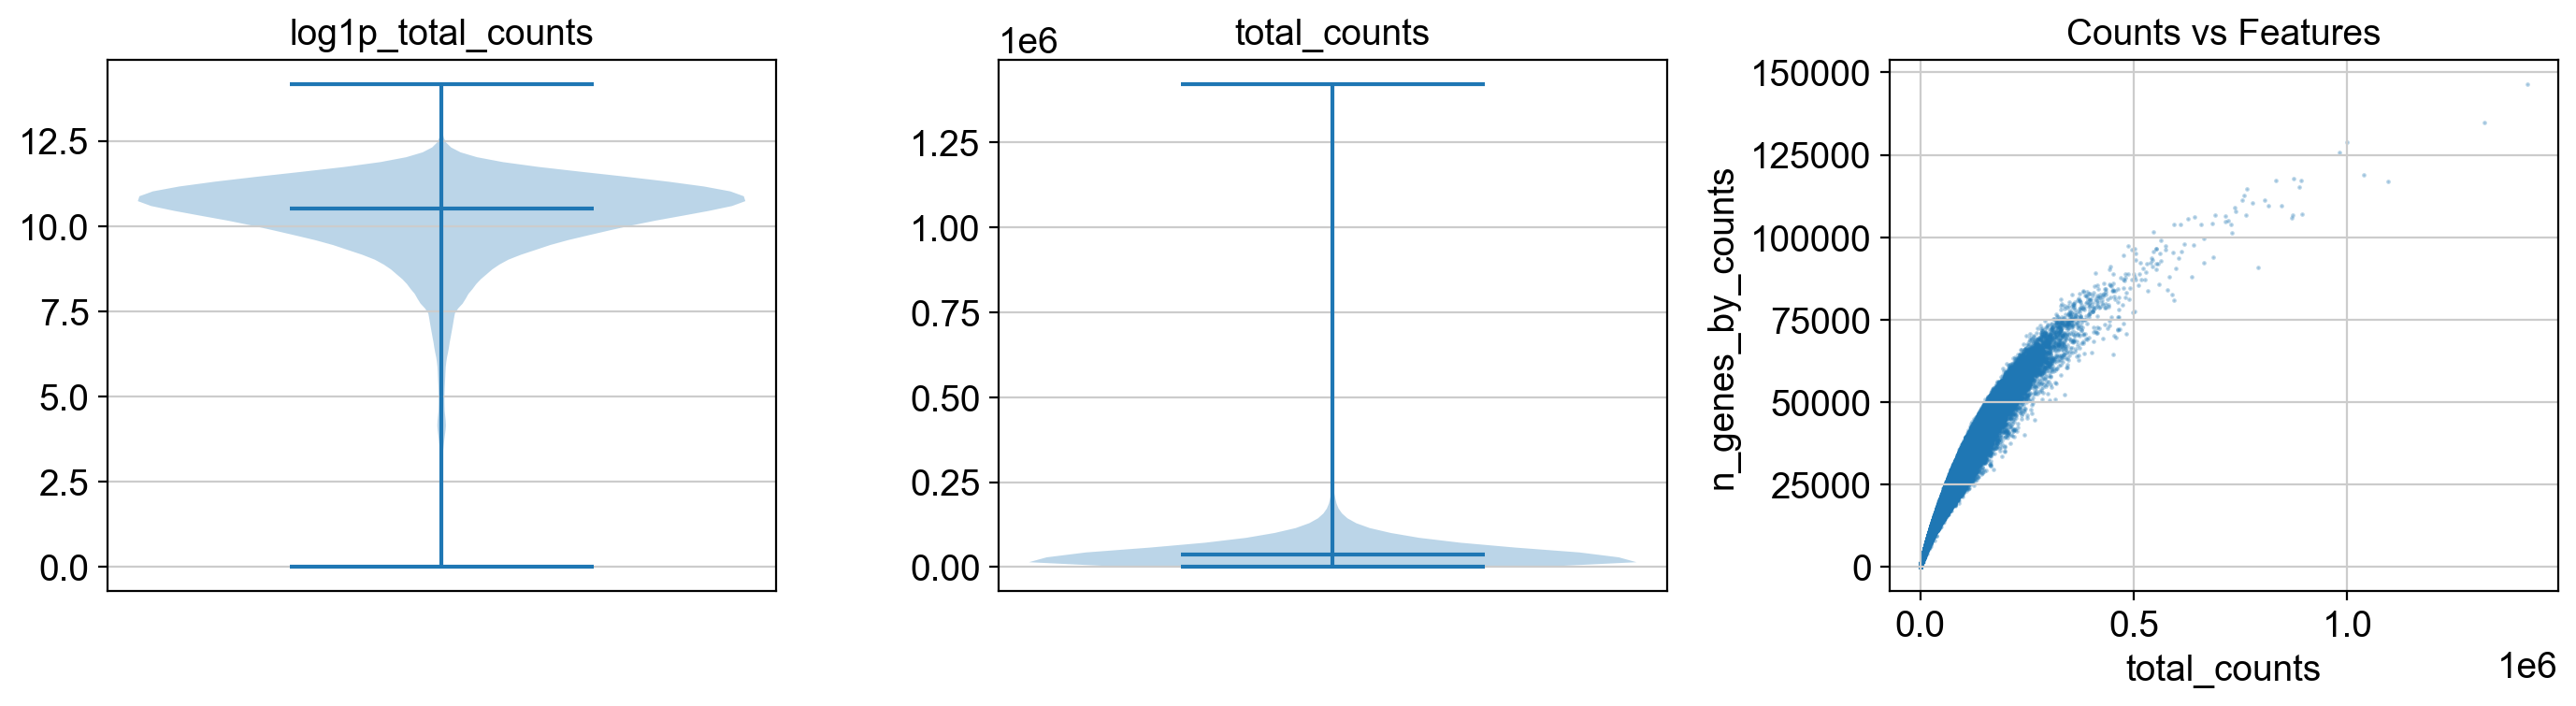

In [5]:
# QC violin plots
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

qc_keys = ["log1p_total_counts", "log1p_n_genes_by_counts"]
# fallback to whatever is available
available = [k for k in ["log1p_total_counts", "total_counts"] if k in adata.obs.columns]
available += [k for k in ["log1p_n_genes_by_counts", "n_genes_by_counts",
                           "n_features_by_counts"] if k in adata.obs.columns]

keys_to_plot = available[:2]  # up to 2 keys for violin

for i, ax in enumerate(axes[:len(keys_to_plot)]):
    ax.violinplot(adata.obs[keys_to_plot[i]].dropna(), showmedians=True)
    ax.set_title(keys_to_plot[i])
    ax.set_xticks([])

# Scatter: total counts vs n_features
xk = [k for k in ["total_counts"] if k in adata.obs.columns]
yk = [k for k in ["n_genes_by_counts", "n_features_by_counts"] if k in adata.obs.columns]
if xk and yk:
    axes[2].scatter(adata.obs[xk[0]], adata.obs[yk[0]], s=0.5, alpha=0.3, rasterized=True)
    axes[2].set_xlabel(xk[0])
    axes[2].set_ylabel(yk[0])
    axes[2].set_title("Counts vs Features")

plt.tight_layout()
plt.show()

In [6]:
print(f"Before filtering: {adata.n_obs} cells × {adata.n_vars} peaks")

# --- Cell-level thresholds (adjust based on QC plots above) ---
feat_col = next((c for c in ["n_genes_by_counts", "n_features_by_counts"] if c in adata.obs.columns), None)

if feat_col:
    MIN_PEAKS = 200
    MAX_PEAKS = np.quantile(adata.obs[feat_col], 0.99)  # remove top 1% outliers

    cell_mask = (adata.obs[feat_col] >= MIN_PEAKS) & (adata.obs[feat_col] <= MAX_PEAKS)
    adata = adata[cell_mask].copy()
    print(f"After cell filter (peaks {MIN_PEAKS}–{int(MAX_PEAKS)}): {adata.n_obs} cells")

# --- Peak-level filter: keep peaks accessible in ≥ 5 cells ---
sc.pp.filter_genes(adata, min_cells=5)

print(f"After peak filter (min_cells=5): {adata.n_obs} cells × {adata.n_vars} peaks")

Before filtering: 1123761 cells × 218882 peaks


After cell filter (peaks 200–47515): 1094561 cells
After peak filter (min_cells=5): 1094561 cells × 218882 peaks


In [7]:
import os

OUT_DIR = "../data/processed/"
os.makedirs(OUT_DIR, exist_ok=True)

OUT_PATH = os.path.join(OUT_DIR, "MTG_scATACseq_QC_filtered.h5ad")
adata.write_h5ad(OUT_PATH)
print(f"Saved: {OUT_PATH}")
print(adata)

Saved: ../data/processed/MTG_scATACseq_QC_filtered.h5ad
AnnData object with n_obs × n_vars = 1094561 × 218882
    obs: 'sample_id', 'Neurotypical reference', 'Donor ID', 'Organism', 'Brain Region', 'Sex', 'Gender', 'Age at Death', 'Race (choice=White)', 'Race (choice=Black/ African American)', 'Race (choice=Asian)', 'Race (choice=American Indian/ Alaska Native)', 'Race (choice=Native Hawaiian or Pacific Islander)', 'Race (choice=Unknown or unreported)', 'Race (choice=Other)', 'specify other race', 'Hispanic/Latino', 'Highest level of education', 'Years of education', 'PMI', 'Fresh Brain Weight', 'Brain pH', 'Overall AD neuropathological Change', 'Thal', 'Braak', 'CERAD score', 'Overall CAA Score', 'Highest Lewy Body Disease', 'Total Microinfarcts (not observed grossly)', 'Total microinfarcts in screening sections', 'Atherosclerosis', 'Arteriolosclerosis', 'LATE', 'Cognitive Status', 'Last CASI Score', 'Interval from last CASI in months', 'Last MMSE Score', 'Interval from last MMSE in m

In [5]:
# CELLULE 7 : DIAGNOSTIC POST-QC
print("=== POST-FILTRAGE ===")
print(f"Cellules gardées: {adata.n_obs:,} ({adata.n_obs/1_123_761*100:.1f}% du brut)")
print(f"Peaks gardés: {adata.n_vars:,}")
print(f"Densité: {adata.X.nnz/(adata.n_obs*adata.n_vars)*100:.3f}%")

print("\n=== DONNEURS ===")
print(adata.obs['Donor ID'].value_counts().head())
print(f"Donneurs uniques: {adata.obs['Donor ID'].nunique()}")

print("\n=== QUALITÉ RESTANTE ===")
qc_cols = ['ATAC_TSS_enrichment_score', 'ATAC_Median_high_quality_fragments_per_cell']
for col in qc_cols:
    if col in adata.obs:
        print(f"{col}: médiane={adata.obs[col].median():.1f}, P5-P95={adata.obs[col].quantile([0.05,0.95]).values}")


=== POST-FILTRAGE ===
Cellules gardées: 1,094,561 (97.4% du brut)
Peaks gardés: 218,882
Densité: 7.292%

=== DONNEURS ===
Donor ID
H21.33.019    35645
H20.33.002    35092
H20.33.005    29204
H20.33.027    29086
H20.33.014    28626
Name: count, dtype: int64
Donneurs uniques: 86

=== QUALITÉ RESTANTE ===
ATAC_TSS_enrichment_score: médiane=4.6, P5-P95=[3.4186 5.9377]
ATAC_Median_high_quality_fragments_per_cell: médiane=37611.0, P5-P95=[14976.5 71211. ]


In [6]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nNotebook is executing from:")
print(os.path.abspath(os.curdir))

print("\nDirectory contents:")
for item in os.listdir('.')[:10]:  # show first 10 items
    print(f"  {item}")

Current working directory:
/data/boussif/SEA-AD/MTG_scATAC

Notebook is executing from:
/data/boussif/SEA-AD/MTG_scATAC

Directory contents:
  SEAAD_MTG_ATACseq_all-nuclei.2024-12-06.h5ad
  processed
  cell_metadata.csv
  MTG.ipynb


In [7]:
print("Donneurs uniques:", adata.obs['Donor ID'].nunique())
print("Colonnes obs utiles:", ['Donor ID', 'Class', 'Subclass', 'Brain Region'])
print(adata.obs[['Donor ID', 'Class', 'Subclass']].head())


Donneurs uniques: 86
Colonnes obs utiles: ['Donor ID', 'Class', 'Subclass', 'Brain Region']
                                                  Donor ID  \
index                                                        
CTTCTAACACAAGGGT-L8AT_211215_01_G07-1149773124  H21.33.025   
TGTAAAGCACATTAAC-L8XR_210805_01_H09-1124629228  H20.33.025   
TAGACTGCATCCTGGG-L8AT_210916_01_B08-1131409693  H21.33.003   
CGTTGCAAGTCTATGA-L8XR_210805_01_H09-1124629228  H20.33.025   
CCGTGAGTCGTCCCAT-L8AT_211011_01_B01-1136687632  H21.33.008   

                                                                  Class  \
index                                                                     
CTTCTAACACAAGGGT-L8AT_211215_01_G07-1149773124  Neuronal: Glutamatergic   
TGTAAAGCACATTAAC-L8XR_210805_01_H09-1124629228  Neuronal: Glutamatergic   
TAGACTGCATCCTGGG-L8AT_210916_01_B08-1131409693  Neuronal: Glutamatergic   
CGTTGCAAGTCTATGA-L8XR_210805_01_H09-1124629228  Neuronal: Glutamatergic   
CCGTGAGTCGTCCCAT-L8AT_2

In [11]:
import psutil
from scipy.sparse import issparse
ram = psutil.virtual_memory()
print(f"RAM disponible : {ram.available / 1e9:.1f} GB")
print(f"RAM totale : {ram.total / 1e9:.1f} GB")
print(f"Type des données : {adata.X.dtype}")

print(f"Matrice sparse ? : {issparse(adata.X)}")


RAM disponible : 572.8 GB
RAM totale : 1621.9 GB
Type des données : float32
Matrice sparse ? : True


In [12]:
# Prendre UN SEUL donneur pour tester
donor_test = adata.obs['Donor ID'].unique()[0]
print(f"Donneur test : {donor_test}")

# Sélectionner ses cellules
mask = adata.obs['Donor ID'] == donor_test
X_donor = adata[mask].X

print(f"Nombre de cellules pour ce donneur : {mask.sum()}")
print(f"Shape sous-matrice : {X_donor.shape}")
print(f"Sparse ? : {issparse(X_donor)}")

# Sommer toutes les cellules → 1 vecteur de 218882 valeurs
if issparse(X_donor):
    pseudobulk_donor = np.array(X_donor.sum(axis=0)).flatten()
else:
    pseudobulk_donor = X_donor.sum(axis=0)

print(f"Shape vecteur pseudobulk : {pseudobulk_donor.shape}")
print(f"5 premières valeurs : {pseudobulk_donor[:5]}")


Donneur test : H21.33.025
Nombre de cellules pour ce donneur : 7666
Shape sous-matrice : (7666, 218882)
Sparse ? : True
Shape vecteur pseudobulk : (218882,)
5 premières valeurs : [1057. 3443.  595.  210. 1137.]


In [13]:
donors = adata.obs['Donor ID'].unique()
print(f"Nombre de donneurs : {len(donors)}")

pseudobulk_dict = {}

for i, donor in enumerate(donors):
    mask = adata.obs['Donor ID'] == donor
    X_donor = adata[mask].X
    pseudobulk_dict[donor] = np.array(X_donor.sum(axis=0)).flatten()
    
    if i % 10 == 0:
        print(f"  {i+1}/{len(donors)} donneurs traités...")

print("✅ Agrégation terminée !")

Nombre de donneurs : 86
  1/86 donneurs traités...
  11/86 donneurs traités...
  21/86 donneurs traités...
  31/86 donneurs traités...
  41/86 donneurs traités...
  51/86 donneurs traités...
  61/86 donneurs traités...
  71/86 donneurs traités...
  81/86 donneurs traités...
✅ Agrégation terminée !


In [14]:
# Construire le DataFrame (donneurs en colonnes, peaks en lignes)
pseudobulk_T = pd.DataFrame(pseudobulk_dict, index=adata.var.index)

print("Shape finale (peaks × donneurs):", pseudobulk_T.shape)
# attendu : (218882, 86)
print(pseudobulk_T.iloc[:5, :5])

Shape finale (peaks × donneurs): (218882, 86)
                          H21.33.025  H20.33.025  H21.33.003  H21.33.008  \
chr4:164130572-164131513      1057.0      2203.0      1390.0      1523.0   
chr4:16412872-16415576        3443.0      9375.0      4282.0      4005.0   
chr4:164116366-164116739       595.0       898.0       735.0       897.0   
chr4:164083047-164083256       210.0       418.0       255.0       432.0   
chr4:164056041-164057013      1137.0      1187.0      1046.0      1290.0   

                          H21.33.038  
chr4:164130572-164131513       521.0  
chr4:16412872-16415576        1092.0  
chr4:164116366-164116739       489.0  
chr4:164083047-164083256       151.0  
chr4:164056041-164057013       608.0  


In [15]:
pseudobulk_T.to_csv("../data/processed/MTG_AD_pseudobulk.tsv", sep="\t")
print("✅ Count matrix sauvegardée !")


✅ Count matrix sauvegardée !


In [21]:
metadata_sc = (
    adata.obs[[
        'Donor ID',
        'Sex',
        'Age at Death',
        'PMI',
        'Brain Region',
        'APOE Genotype',
        'Overall AD neuropathological Change',
        'Braak',
        'CERAD score',
        'Cognitive Status',
        'Continuous Pseudo-progression Score',
        'Severely Affected Donor'
    ]]
    .drop_duplicates(subset='Donor ID')
    .set_index('Donor ID')
)

print("Shape metadata:", metadata_sc.shape)
# attendu : (86, 11)
print(metadata_sc.head(3))

metadata_sc.to_csv("../data/metadata/metadata_scATAC_MTG_pseudobulk.tsv", sep="\t")
print("✅ Metadata sauvegardé !")


Shape metadata: (86, 11)
               Sex  Age at Death   PMI Brain Region APOE Genotype  \
Donor ID                                                            
H21.33.025  Female          88.0   8.6    Human MTG           3/3   
H20.33.025    Male          94.0   4.5    Human MTG           3/3   
H21.33.003    Male          78.0  10.0    Human MTG           3/3   

           Overall AD neuropathological Change     Braak CERAD score  \
Donor ID                                                               
H21.33.025                        Intermediate  Braak IV    Moderate   
H20.33.025                                High   Braak V    Moderate   
H21.33.003                              Not AD   Braak 0      Absent   

           Cognitive Status  Continuous Pseudo-progression Score  \
Donor ID                                                           
H21.33.025      No dementia                             0.518005   
H20.33.025      No dementia                             0.588882

In [22]:
metadata_sc

,Sex,Age at Death,PMI,Brain Region,APOE Genotype,Overall AD neuropathological Change,Braak,CERAD score,Cognitive Status,Continuous Pseudo-progression Score,Severely Affected Donor
Donor ID,,,,,,,,,,,
H21.33.025,Female,88.0,8.6,Human MTG,3/3,Intermediate,Braak IV,Moderate,No dementia,0.518005,N
H20.33.025,Male,94.0,4.5,Human MTG,3/3,High,Braak V,Moderate,No dementia,0.588882,N
H21.33.003,Male,78.0,10.0,Human MTG,3/3,Not AD,Braak 0,Absent,No dementia,0.238033,N
H21.33.008,Female,91.0,5.0,Human MTG,3/3,High,Braak V,Frequent,Dementia,0.790347,N
H21.33.038,Female,84.0,11.0,Human MTG,3/3,Low,Braak III,Absent,No dementia,0.182370,N
...,...,...,...,...,...,...,...,...,...,...,...
H20.33.034,Female,85.0,10.016666666667,Human MTG,2/2,Intermediate,Braak IV,Absent,No dementia,0.368330,N
H21.33.002,Female,70.0,3.2,Human MTG,3/4,High,Braak VI,Frequent,Dementia,0.856821,N
H21.33.015,Male,98.0,4.1,Human MTG,3/3,Low,Braak IV,Sparse,No dementia,0.230781,N


In [23]:
print(adata.obs['Class'].value_counts())
print(adata.obs['Subclass'].value_counts().head(20))


Class
Neuronal: Glutamatergic        755634
Neuronal: GABAergic            195594
Non-neuronal and Non-neural    143333
Name: count, dtype: int64
Subclass
L2/3 IT            207001
L5 IT              113527
L4 IT               89269
Oligodendrocyte     54084
Vip                 52247
Pvalb               48732
Sst                 39861
Astrocyte           35636
L6 IT               23531
Lamp5               22088
Microglia-PVM       19047
VLMC                18491
OPC                 15579
L6 IT Car3          13241
Sncg                11921
Lamp5 Lhx6          11324
L5/6 NP             10075
L6 CT                7801
L6b                  6525
Pax6                 4510
Name: count, dtype: int64


In [4]:
metadata_sc = pd.read_csv("../data/metadata/metadata_scATAC_MTG_pseudobulk.tsv", sep="\t", index_col=0)
print("Shape metadata:", metadata_sc.shape)
print(f'index name: {metadata_sc.index.name}')

Shape metadata: (86, 11)
index name: Sample


In [27]:
metadata_sc.index.name = 'Sample'
metadata_sc.reset_index().to_csv("../data/metadata/metadata_scATAC_MTG_pseudobulk.tsv", sep="\t", index=False)

## QC Summary Plots

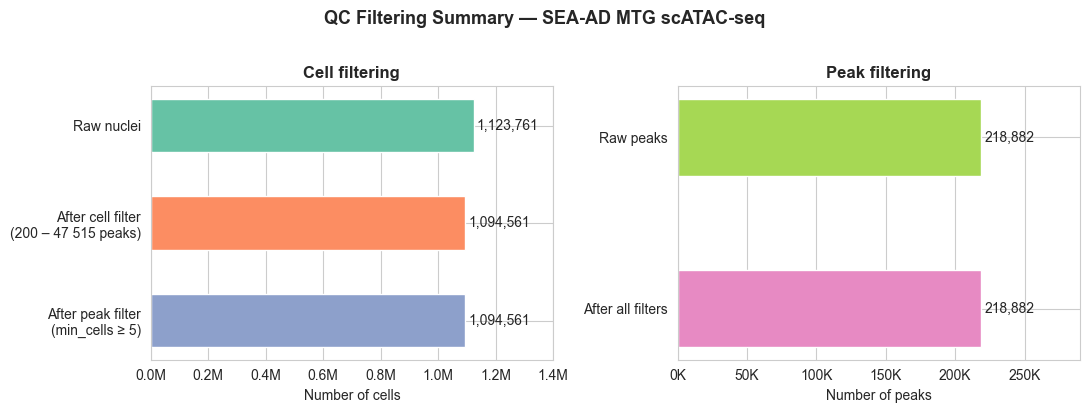

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_style("whitegrid")
palette = sns.color_palette("Set2")

# ═══════════════════════════════════════════════════════════════
# PLOT 1 — Filtering funnel (cells & peaks)
# ═══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# — Cells —
labels_c = ["Raw nuclei", "After cell filter\n(200 – 47 515 peaks)", "After peak filter\n(min_cells ≥ 5)"]
values_c = [1_123_761, 1_094_561, 1_094_561]
colors_c = [palette[0], palette[1], palette[2]]
bars = axes[0].barh(labels_c[::-1], values_c[::-1], color=colors_c[::-1],
                    edgecolor="white", height=0.55)
for bar, v in zip(bars, values_c[::-1]):
    axes[0].text(bar.get_width() + 10_000, bar.get_y() + bar.get_height() / 2,
                 f"{v:,}", va="center", fontsize=10)
axes[0].set_xlabel("Number of cells")
axes[0].set_title("Cell filtering", fontweight="bold")
axes[0].set_xlim(0, 1_400_000)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

# — Peaks —
labels_p = ["Raw peaks", "After all filters"]
values_p = [218_882, 218_882]
bars2 = axes[1].barh(labels_p[::-1], values_p[::-1],
                     color=[palette[3], palette[4]], edgecolor="white", height=0.45)
for bar, v in zip(bars2, values_p[::-1]):
    axes[1].text(bar.get_width() + 2_500, bar.get_y() + bar.get_height() / 2,
                 f"{v:,}", va="center", fontsize=10)
axes[1].set_xlabel("Number of peaks")
axes[1].set_title("Peak filtering", fontweight="bold")
axes[1].set_xlim(0, 290_000)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))

plt.suptitle("QC Filtering Summary — SEA-AD MTG scATAC-seq", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("qc_filtering_funnel.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ═══════════════════════════════════════════════════════════════
# PLOT 2 — Approximate QC distributions from summary statistics
# (reconstructed from describe() output)
# ═══════════════════════════════════════════════════════════════

# Summary stats from the raw QC (before filtering)
stats = {
    "n_genes_by_counts": {"mean": 16090.82, "std": 10962.91, "min": 0, "25%": 7604, "50%": 14553, "75%": 22678, "max": 146467},
    "total_counts":      {"mean": 45478.67, "std": 38117.98, "min": 0, "25%": 17695, "50%": 37175, "75%": 63272, "max": 1422007},
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (metric, s) in zip(axes, stats.items()):
    # Generate synthetic sample matching the summary statistics
    rng = np.random.default_rng(42)
    synthetic = rng.normal(loc=s["mean"], scale=s["std"], size=50_000)
    synthetic = np.clip(synthetic, s["min"], s["max"])

    ax.hist(synthetic, bins=80, color=palette[0], edgecolor="white", alpha=0.85, density=True)

    # Mark key percentiles
    for q, label, ls in [(s["25%"], "Q1", "--"), (s["50%"], "Median", "-"), (s["75%"], "Q3", "--")]:
        ax.axvline(q, color="crimson", ls=ls, lw=1.3, alpha=0.8)
        ax.text(q, ax.get_ylim()[1] * 0.92, f" {label}\n {q:,.0f}", fontsize=8,
                color="crimson", ha="left", va="top")

    nice = metric.replace("_", " ").title()
    ax.set_title(nice, fontweight="bold")
    ax.set_xlabel(nice)
    ax.set_ylabel("Density")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))

plt.suptitle("QC Metric Distributions (pre-filtering, N = 1 123 761 cells)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("qc_distributions.png", dpi=150, bbox_inches="tight")
plt.show()